
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E03_overfit_regularization.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Overfit and regularization exercises 

---
These are introductory exercises in Machine learning with focus in **overfitting and regularization** .

<p class = "alert alert-info" role="alert"><b>Note</b> that sometimes you don't get exactly the same answer as I get, but it doesn't neccessarily mean it is wrong. Could be some parameters, randomization, that we have different. Also very important is that in the future there won't be any answer sheets, use your skills in data analysis, mathematics and statistics to back up your work.</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Tips data EDA (*)

In the whole exercise, we will work with the "tips" dataset from seaborn dataset. Start by loading dataset "tips" from the ```load_dataset``` method in seaborn module. The goal will be to use polynomial linear regression to predict tips. 

&nbsp; a) Start by doing some initial EDA such as info(), describe().

&nbsp; b) Use describe only on those columns that are relevant to get statistical information from. Plot the descriptive statistics for each numerical column, with a adequate plot type (e.g. barplot).

&nbsp; c) Based on the initial EDA, make some more plots on things you think could be worthwhile to investigate. 

&nbsp; d) Try discuss your findings with yourself/colleague and draw some conclusions if possible. Note that in reality, it is important to be able to communicate your findings so that other people in your team/customers/stakeholders etc. get an understanding of the data and realizes the importance of your role as a data scientist/analyst.

<details>

<summary>Answer</summary>


b)
<img src="../assets/df_describe.png" height="300"/>

c) Here are some example plots

<img src="../assets/tips_EDA.png" height="300"/>

<img src="../assets/tips_smoke_sex.png" width="500"/>

<img src="../assets/tips_bar_sex.png" width="300"/>


d) For example: 
- there are almost double amount of females represented in the dataset
- there are very few tables with 1 person eating, and they usually give very low tip
- female and male tip somewhat similar

</details>

---

In [213]:
from seaborn import load_dataset
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


df = sns.load_dataset('tips')

# a

print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [215]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [216]:
# b

df[['total_bill', 'tip', 'size']].describe()


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 1. Train|test split (*)

Split the data into training part and testing part, using sklearn's train_test_split with test size of 0.3 and random_state 42.

In [217]:
from sklearn.model_selection import train_test_split

X = df[['total_bill', 'size']] 
y = df['tip']  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


---
## 2. Feature standardization (*)

We need to normalize the data and in this case will be using feature standardization. Implement this yourself following this formula:

$$X_{train}' = \frac{X_{train}-\mu_{train}}{\sigma_{train}}$$

$$X_{test}' = \frac{X_{test}-\mu_{train}}{\sigma_{train}}$$

, where $'$ denotes scaled, $\mu_{train}$ is the mean of the training data, $\sigma_{train}$ is the standard deviation of the training data. Note that it is very important that the mean and standard deviation is computed from the training data and not from testing data to avoid data leakage. Control the standard deviation and mean of $X_{train}'$ and $X_{test}'$. Is the results as you expect, why, why not?

<details>

<summary>Answer</summary>

scaled_X_train (total_bill, size) mean: [ 6.79195262e-17 -1.98534000e-16]

scaled_X_test (total_bill, size) mean: [-0.19137999 -0.04477934]

scaled_X_train (total_bill, size) std: [1. 1.]

scaled_X_test (total_bill, size) std: [0.92495673 1.06638889]

</details>

In [218]:

mu_train = X_train.mean()
sigma_train = X_train.std()


X_train_scaled = (X_train - mu_train) / sigma_train


X_test_scaled = (X_test - mu_train) / sigma_train


print("Mean of X_train_scaled:", X_train_scaled.mean())
print("Std of X_train_scaled:", X_train_scaled.std())
print("Mean of X_test_scaled:", X_test_scaled.mean())
print("Std of X_test_scaled:", X_test_scaled.std())


Mean of X_train_scaled: total_bill    6.791953e-17
size         -1.985340e-16
dtype: float64
Std of X_train_scaled: total_bill    1.0
size          1.0
dtype: float64
Mean of X_test_scaled: total_bill   -0.191380
size         -0.044779
dtype: float64
Std of X_test_scaled: total_bill    0.924957
size          1.066389
dtype: float64


---
## 3. Polynomial features (*)

We want to investigate ```Polynomialfeatures``` from scikit-klearn in this task. Start by instantiating an object of type ```PolynomialFeatures``` with degree 2. Now do the following: 

- use the method fit on $X_{train}'$
- transform $X_{train}'$
- transform $X_{test}'$

Compare this transformed $X_{test}'$ with $X_{test}''$ where $X_{test}''$ comes from fitting the polynomial features to $X_{test}'$ and transforming $X_{test}'$. You can check directly by using ```==``` and then sum it up. If the value is same as the length, then you know that they are the same, as a boolean True evaluates to 1. 


In [219]:
from sklearn.preprocessing import PolynomialFeatures

model_poly = PolynomialFeatures(degree=2)


X_train_poly_fit = model_poly.fit_transform(X_train)
X_train_poly_transform = model_poly.transform(X_train)

X_test_poly_transform = model_poly.transform(X_test)
X_test_poly_fit = model_poly.fit_transform(X_test)

are_equal = (X_test_poly_transform == X_test_poly_fit).all()
print(f"Equal? {are_equal}")


Equal? True


---
## 4. Polynomial regression  (*)

We will now investigate the training loss and testing loss for different degrees of polynomial. Loop through degrees 1 to 4 (inclusive) and:
- instantiate an object of PolynomialFeatures with that degree
- fit and transform $X_{train}'$ and $X_{test}$ to create polynomial features
- perform linear regression on these polynomial features (polynomial regression)
- predict on both the training and testing data to record RMSE for training and testing for each iteration of the loop

Now plot the results in the same figure. Do you notice anything special? 

<details>

<summary>Answer</summary>

<img src="../assets/E3_overfitting.png" height="300"/>

</details>

In [220]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

train_rmse_list = []
test_rmse_list = []

for i in range(1, 5):  
    # Först så skapar jag en Polynomiel modell och gör "fit" och "transform" på train/test
    model_poly = PolynomialFeatures(degree=i)  
    X_train_poly = model_poly.fit_transform(X_train)
    X_test_poly = model_poly.transform(X_test) 
    
    # Därefter så skapar jag en "vanlig" linjär regressionsmodell och gör "fit" som vanligt. 
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Samma här, fast "predict"
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Här hämtar jag RMSE-värdet ifrån train och test
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

    print(f"Polynomial Degree: {i} | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")


Polynomial Degree: 1 | Train RMSE: 1.0518 | Test RMSE: 0.9181
Polynomial Degree: 2 | Train RMSE: 1.0455 | Test RMSE: 0.9507
Polynomial Degree: 3 | Train RMSE: 0.9834 | Test RMSE: 1.0492
Polynomial Degree: 4 | Train RMSE: 0.9052 | Test RMSE: 2.6976


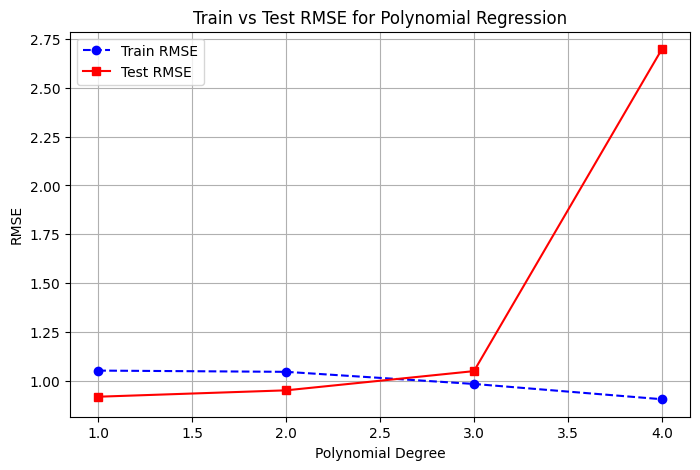

In [221]:
import matplotlib.pyplot as plt


degrees = list(range(1, 5))


plt.figure(figsize=(8, 5))
plt.plot(degrees, train_rmse_list, marker='o', linestyle='--', color='blue', label='Train RMSE')
plt.plot(degrees, test_rmse_list, marker='s', linestyle='-', color='red', label='Test RMSE')


plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Train vs Test RMSE for Polynomial Regression")
plt.legend()
plt.grid(True)


plt.show()


From degree = 3 and higher, the test-data RMSE soars away from the train-data's RMSE. This indicates that the model is not nearly as precise as it was in lower degrees.

### Personlig påminnelse 

**RMSE = Root Mean Squared Error**  
RMSE visar hur stor den genomsnittliga avvikelsen är mellan de förutsagda värdena och de verkliga värdena i en modell.  

#### **Varför är RMSE viktigt?**
- RMSE mäter **modellens noggrannhet** – lägre värden betyder bättre prediktioner.  
- Eftersom det är i **samma enhet som det predikterade värdet**, är det lätt att tolka.  
- RMSE är särskilt användbart i **regressionsmodeller**, där vi vill minimera felen.

#### **Hur tolkar man RMSE i maskininlärning?**
- **Låg RMSE** → Modellen gör noggranna förutsägelser.  
- **Hög RMSE** → Modellen har stora fel och presterar dåligt.  
- **Om RMSE är mycket lägre på träning än test** → **Overfitting** (modellen är för anpassad till träningsdatan).  
- **Om RMSE är högt på både träning och test** → **Underfitting** (modellen är för enkel och fångar inte upp mönster).  

#### **Vad kan man göra om RMSE är för högt?**
- **Vid överfitting:**  
  - Testa färre polynoma grader (om polynomregression används).  
  - Lägg till **regularisering** som Ridge eller Lasso.  
  - Skaffa mer träningsdata.  

- **Vid underfitting:**  
  - Testa en mer komplex modell (t.ex. högre polynomgrad).  
  - Lägg till fler relevanta features i modellen.  
  - Undersök om data behöver transformeras eller normaliseras.

---

**Sammanfattning:**  
RMSE är ett mått på hur mycket modellen felar i sina prediktioner. Ett lågt RMSE betyder en bra modell, medan ett högt RMSE kan signalera antingen överfitting eller underfitting.


---
## 5. Regularization methods (*)

Now we will try the regularization methods: ridge regression, lasso regression and elasticnet regression. In the following tasks, use degree = 4. 

&nbsp; a) Use ridge regression with cross-validation and test out different alpha-values. I used $\alpha=[0.01, 0.1, 0.5, 1, 5, 10]$ in the cross-validation. 
- Check which alpha, that the cross-validation chose as the best one. 
- Check the weights.
- Check MAE, MSE, RMSE.

&nbsp; b) Use lasso regression with cross-validation and choose number of alphas to 100. If you get a warning that the algorithm is not converging, increase the max iterations, I chose 10000 iterations. 
- Check which alpha, that the cross-validation chose as the best one. 
- Check the weights.
- Check MAE, MSE, RMSE.

&nbsp; c) Use elasticnet regression with cross-validation and choose number of alphas to 100. If you get a warning that the algorithm is not converging, increase the max iterations, I chose 10000 iterations. Choose a set of $\ell_1$ ratios for it to try out. I chose $\ell_1 = [.001, .01, .05, .1, .5, .9, .95, 1]$
- Check which alpha, that the cross-validation chose as the best one. 
- Check the weights.
- Check MAE, MSE, RMSE.

<details>

<summary>Answer</summary>

a) 

Chosen alpha from cross-validation 5.0

Weights: [ 0.          0.91469637  0.23893931 -0.67583593  0.20550801 -0.01369317
 -0.26007685  0.31867863 -0.03429744 -0.12484035  0.16000319 -0.18105113
  0.24878399 -0.12692847  0.05002613]

Mean absolute error: 0.831

Mean squared error: 2.208

Root mean squared error: 1.486

b) 

Chosen alpha from cross-validation 0.208

Weights: [ 0.          0.23469707  0.         -0.         -0.          0.
  0.08814685  0.09735986  0.          0.03219702  0.          0.
  0.         -0.          0.        ]

Mean absolute error: 0.823

Mean squared error: 1.345

Root mean squared error: 1.160

c)

Chosen alpha from cross-validation 0.107

Mean absolute error: 0.761

Root mean squared error: 1.139

L1_ratio: 0.9

Weights: [ 0.          0.23469707  0.         -0.         -0.          0.
  0.08814685  0.09735986  0.          0.03219702  0.          0.
  0.         -0.          0.        ]


</details>

In [222]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

X_train_poly = model_poly.fit_transform(X_train_scaled)
X_test_poly = model_poly.transform(X_test_scaled) 


alpha_values = [0.01, 0.1, 0.5, 1, 5, 10]
ridge_model = RidgeCV(alphas=alpha_values)  
ridge_model.fit(X_train_poly, y_train)

y_pred = ridge_model.predict(X_test_poly)

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

print(f"Bästa alpha: {ridge_model.alpha_}")
print(f"Vikter: {ridge_model.coef_}")
print(f"MAE: {MAE:.4f}")
print(f"MSE: {MSE:.4f}")
print(f"RMSE: {RMSE:.4f}")




Bästa alpha: 5.0
Vikter: [ 0.          0.91469637  0.23893931 -0.67583593  0.20550801 -0.01369317
 -0.26007685  0.31867863 -0.03429744 -0.12484035  0.16000319 -0.18105113
  0.24878399 -0.12692847  0.05002613]
MAE: 0.8306
MSE: 2.2075
RMSE: 1.4858


In [223]:
from sklearn.linear_model import LassoCV

alpha_values = np.logspace(-3, 1, 100) 
lasso_model = LassoCV(n_alphas=100, cv=5, max_iter=10000)  


lasso_model.fit(X_train_poly, y_train)


y_pred_lasso = lasso_model.predict(X_test_poly)


MAE_lasso = mean_absolute_error(y_test, y_pred_lasso)
MSE_lasso = mean_squared_error(y_test, y_pred_lasso)
RMSE_lasso = np.sqrt(MSE_lasso)


print(f"Bästa alpha (Lasso): {lasso_model.alpha_}")
print(f"Vikter (Lasso): {lasso_model.coef_}")
print(f"MAE (Lasso): {MAE_lasso:.4f}")
print(f"MSE (Lasso): {MSE_lasso:.4f}")
print(f"RMSE (Lasso): {RMSE_lasso:.4f}")


Bästa alpha (Lasso): 0.20770232166587632
Vikter (Lasso): [ 0.          0.23469707  0.         -0.         -0.          0.
  0.08814685  0.09735986  0.          0.03219702  0.          0.
  0.         -0.          0.        ]
MAE (Lasso): 0.8234
MSE (Lasso): 1.3452
RMSE (Lasso): 1.1598


In [224]:
from sklearn.linear_model import ElasticNetCV


alpha_values = np.logspace(-3, 1, 100) 
l1_ratios = [0.001, 0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 1]


elastic_net_model = ElasticNetCV(alphas=alpha_values, l1_ratio=l1_ratios, cv=5, max_iter=100000)


elastic_net_model.fit(X_train_poly, y_train)


y_pred_elastic = elastic_net_model.predict(X_test_poly)

MAE_elastic = mean_absolute_error(y_test, y_pred_elastic)
MSE_elastic = mean_squared_error(y_test, y_pred_elastic)
RMSE_elastic = np.sqrt(MSE_elastic)


print(f"Bästa alpha (ElasticNet): {elastic_net_model.alpha_}")
print(f"Bästa l1_ratio (ElasticNet): {elastic_net_model.l1_ratio_}")
print(f"Vikter (ElasticNet): {elastic_net_model.coef_}")
print(f"MAE (ElasticNet): {MAE_elastic:.4f}")
print(f"MSE (ElasticNet): {MSE_elastic:.4f}")
print(f"RMSE (ElasticNet): {RMSE_elastic:.4f}")


Bästa alpha (ElasticNet): 0.10476157527896651
Bästa l1_ratio (ElasticNet): 0.9
Vikter (ElasticNet): [ 0.          0.5233727   0.10165306 -0.22172206  0.          0.
  0.          0.11438814  0.          0.01775321  0.03809967  0.
  0.          0.          0.        ]
MAE (ElasticNet): 0.7602
MSE (ElasticNet): 1.2991
RMSE (ElasticNet): 1.1398


---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---